In [2]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import special

In [3]:
import scienceplots
plt.style.use("science")

%config InlineBackend.figure_format = 'retina'
mpl.rcParams['figure.dpi']=120 #default is 72. 

In [9]:
prob_data = pd.read_csv("survival_probability_new.csv",sep=",")

x= prob_data["x (L/E)"]
P_ee= prob_data["P_ee"]
P_ee_err= prob_data["P_ee_err"]

prob_data.head()

,x (L/E),P_ee,P_ee_err_min,P_ee_err_max,P_ee_err
0,23.261848,0.588141,0.528376,0.649788,0.121412
1,28.602149,0.639309,0.585662,0.695780,0.110118
2,30.937424,0.687725,0.629842,0.748901,0.119059
3,32.780057,0.866976,0.795917,0.935682,0.139765
4,34.497508,0.722935,0.662700,0.783642,0.120941


In [72]:
P_err=abs(prob_data["P_ee_err_min"]-prob_data["P_ee"])*2

In [73]:
P_err

0     0.119530
1     0.107296
2     0.115766
3     0.142118
4     0.120471
5     0.124236
6     0.097883
7     0.104471
8     0.089413
9     0.079059
10    0.081883
11    0.067764
12    0.099765
13    0.125178
14    0.143059
15    0.160000
16    0.188237
17    0.231531
18    0.422591
19    0.527060
dtype: float64

### Parameter reconstruction for Dark mass hypothesis

#### Dark mass hypothesis:

  $$ P_{ee} = 1 - 2 \cos^{4}\theta_{13}\,\sin^{2}\theta_{12}\,\cos^{2}\theta_{12}\left[1- J_{0}\!\left(X_{21D}\right) \cos\!\left(X_{21D}\right) \right] - 2 \cos^{2}\theta_{13}\,\sin^{2}\theta_{13}.
  $$

Where, $$X_{ijD}= \frac{\Delta m_{ijD}^2\,L}{4 E},$$ where $m_\phi$ is the mass of ULDM, $J_0(z)$ is the bessel function of first kind.

In [74]:
param_names = [r'$\Delta m^{2}_{21}$', r'$\theta_{12}$', r'$\theta_{13}$']

In [75]:
import scipy.stats

def my_prior_transform(cube): # The prior list for parameters
    params = cube.copy()

    # dm21 varies between [1-15]* 10^(-5) eV^2
    hi= 15
    lo= 1
    params[0] = (cube[0] * (hi - lo) + lo) #*10**(-5)

    # theta_12 varies within [0-1]
    params[1] = cube[1]

    # theta_13 varies within [0-1]
    params[2] = cube[2]

    return params

In [76]:
from numpy import log

def my_likelihood(params):
    dm21, theta12, theta13 = params
    
    L = 180 #km
    E = 5 #MeV
    
    # compute intensity at every x position according to the model
    P_ee_dark = 1 - 0.5 * np.cos(theta13)**4 * np.sin(2*theta12)**2 * (1- special.jv(0, 1.27*dm21*x* 10**(-2)) * np.cos(1.27*dm21*x* 10**(-2))) - 0.5 * np.sin(2*theta13)**2
    
    # compare model and data with gaussian likelihood:
    chi2 = np.sum(((P_ee_dark - P_ee)/P_err)**2)
    like = -0.5 * chi2
    return like

In [77]:
import ultranest

sampler = ultranest.ReactiveNestedSampler(param_names, my_likelihood, my_prior_transform)

In [78]:
result = sampler.run(show_status=False, viz_callback=None)
sampler.print_results()

[ultranest] Sampling 400 live points from prior ...
[ultranest] Explored until L=-6  
[ultranest] Likelihood function evaluations: 13294
[ultranest]   logZ = -12.07 +- 0.06716
[ultranest] Effective samples strategy satisfied (ESS = 1982.3, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.06 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.07, need <0.5)
[ultranest]   logZ error budget: single: 0.10 bs:0.07 tail:0.01 total:0.07 required:<0.50
[ultranest] done iterating.

logZ = -12.059 +- 0.149
  single instance: logZ = -12.059 +- 0.101
  bootstrapped   : logZ = -12.070 +- 0.148
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    $\Delta m^{2}_{21}$ : 1.0   │▁▁▁▁▁▁▁▁   ▁▁▁▁▁▁▁▃▇▆▂▁▁▁▁▁ ▁▁▁▁▁▁▁▁▁▁ │15.0      7.6 +- 1.7
    $\theta_{12}$       : 0.00  │▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▃▄▄▆▇▆▇▇▇▇▅▆▅▄▃▂│1.00      0.76 +- 0.13
    $\theta_{13}$       : 0.00  │▆▅▆▇▇▇▇▇▆▄▃▂▁▁▁▁▁▁▁▁▁▁▁

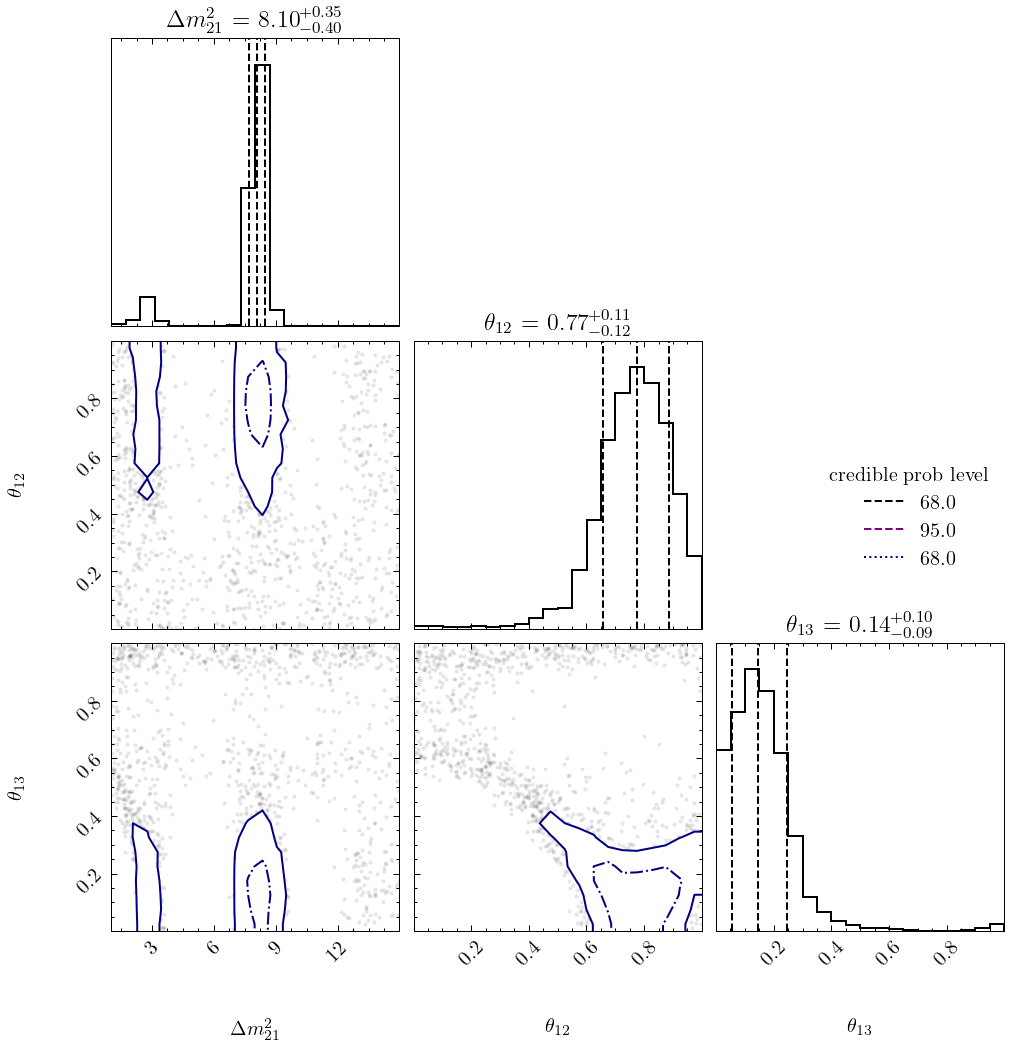

In [79]:
from ultranest.plot import cornerplot
fig= cornerplot(result,
                plot_datapoints=True, 
                levels=[0.68, 0.95],
                quantiles=[0.16, 0.5, 0.84],
                show_titles=True,
                color='black');
# plt.tight_layout()
plt.show()

In [53]:
dm21_dark= result["weighted_samples"]["points"][:,0]
theta12_dark= result["weighted_samples"]["points"][:,1]
theta13_dark= result["weighted_samples"]["points"][:,2]

### Playing with UltraNest

In [38]:
result.keys()

dict_keys(['niter', 'logz', 'logzerr', 'logz_bs', 'logz_single', 'logzerr_tail', 'logzerr_bs', 'ess', 'H', 'Herr', 'posterior', 'weighted_samples', 'samples', 'maximum_likelihood', 'ncall', 'paramnames', 'logzerr_single', 'insertion_order_MWW_test'])

In [80]:
result['logz'],result['logzerr'],result['ess'],result['H']

(-12.05913092519483,
 0.14880025532590793,
 1982.2938446390567,
 4.055758366523582)

In [57]:
result['weighted_samples'].keys()

dict_keys(['upoints', 'points', 'weights', 'logw', 'bootstrapped_weights', 'logl'])

In [88]:
weighted_samples= result['weighted_samples']
weighted_samples['weights']

array([1.65643970e-69, 8.41611773e-68, 6.03877266e-62, ...,
       2.54985004e-05, 2.55038430e-05, 2.55059301e-05])

In [82]:
1/sum(weighted_samples['weights']**2) ## should be equal to ess

1982.293844639141